In [33]:
import xarray as xr
import numpy as np
import pandas as pd
import gsw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.offsetbox import AnchoredText
from shapely.geometry import Polygon
import cartopy.crs as ccrs
from matplotlib.transforms import blended_transform_factory
import yaml
import os
import glob
import xorca_brokenline as bl
from matplotlib.lines import Line2D
from xhistogram.xarray import histogram as xhist
import dask
import dask.distributed
import dask_jobqueue
import seawater as sw
import warnings

warnings.filterwarnings("ignore")

In [2]:
cluster = dask_jobqueue.SLURMCluster(
    # Dask worker size
    cores=4,
    memory="16GB",
    processes=1,  # Dask workers per job
    # SLURM job script things
    queue="base",
    walltime="04:00:00",
    # Dask worker network and temporary storage
    interface="ib0",
    local_directory="$TMPDIR",  # for spilling tmp data to disk
    log_directory="slurm/",
)

client = dask.distributed.Client(cluster)

cluster.scale(jobs=15)  # 15
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.18.4.22:37987/status,
Dashboard: http://172.18.4.22:37987/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.18.4.22:35615,Workers: 0
Dashboard: http://172.18.4.22:37987/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
# converting the age from nano seconds
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
hours_to_days = 0.0416667
hours_to_months = 0.00136986
hours_to_years = 0.000114155
time_conversion = hours_to_days
velocity_conversion = (
    1852 * 60
)  # multiply the value of the V field with 1852 * 60 (the number of meters in 1 degree of latitude)

mesh_mask = xr.open_dataset(inpath + "mesh_masks/mesh_mask.nc")
mesh_hzgr = xr.open_dataset(inpath + "mesh_masks/mesh_hzgr.nc")
mesh_hgr = xr.open_dataset(inpath + "mesh_masks/mesh_hgr.nc")

z = mesh_hzgr.e3t_0
t_mask = mesh_mask.tmask

# bathymetry (Depth level) at every grid point
bathymetry = (
    (z * t_mask)
    .isel(t=0)
    .sum(dim="z")
    .assign_coords({"nav_lat": mesh_hgr.nav_lat, "nav_lon": mesh_hgr.nav_lon})
)

# turn zeros into nans, easier to see where continents are
bath_total_nans = bathymetry.where(bathymetry != 0)
land_mask = mesh_mask.tmask.where(mesh_mask.tmask != 0).isel(t=0, z=0)

In [5]:
def season_mean(ds, calendar="standard"):
    # Make a DataArray with the number of days in each month, size = len(time_counter)
    month_length = ds.time_counter.dt.days_in_month

    # Calculate the weights by grouping by 'time_counter.season'
    weights = (
        month_length.groupby("time_counter.season")
        / month_length.groupby("time_counter.season").sum()
    )

    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(
        weights.groupby("time_counter.season").sum().values, np.ones(4)
    )

    # Calculate the weighted average
    return (ds * weights).groupby("time_counter.season").sum(dim="time_counter")


def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return fit, da - fit


S_trspt = xr.open_dataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/notebooks/CLEANUP_notebooks/S_trspt_1.nc"
).S_trspt
S_trspt_seasonlity_remove = S_trspt.groupby("time_counter.month") - S_trspt.groupby(
    "time_counter.month"
).mean(dim="time_counter")
S_trspt_seasonlity_remove_detrend = detrend_dim(
    S_trspt_seasonlity_remove, "time_counter"
)[1]


S_trspt_detrend = detrend_dim(
    S_trspt_seasonlity_remove.rolling(time_counter=12, center=True).mean(),
    dim="time_counter",
)[1].sel(time_counter=slice("1996", "2019"))

In [6]:
FBC_overflow_trspt = pd.read_csv(
    "/gxfs_work/geomar/smomw452/GLORYS12/Data/observations/FBC_overflow_transport.txt",
    delim_whitespace=True,
)


# Function to convert decimal year to datetime
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    fractional_year = decimal_year - year
    start_of_year = pd.Timestamp(f"{year}-01-01")
    # Approximate days in year (assuming non-leap year for simplicity)
    days_in_year = 365
    days_passed = int(fractional_year * days_in_year)
    return start_of_year + pd.Timedelta(days=days_passed)


# Apply function to DataFrame
FBC_overflow_trspt["Date"] = FBC_overflow_trspt["Year"].apply(decimal_year_to_datetime)

FBC_overflow_trspt["Date"] = pd.to_datetime(FBC_overflow_trspt["Date"])

FBC_overflow_trspt.set_index("Date", inplace=True)
FBC_overflow_trspt_monthly_means = FBC_overflow_trspt["Flux"].resample("M").mean()

FBC_trspt_obs_xr = FBC_overflow_trspt_monthly_means.to_xarray().rename(
    {"Date": "time_counter"}
)
FBC_trspt_obs_seasonality_remove = FBC_trspt_obs_xr.groupby(
    "time_counter.month"
) - FBC_trspt_obs_xr.groupby("time_counter.month").mean(dim="time_counter")
FBC_obs_trspt_detrend = detrend_dim(
    FBC_trspt_obs_xr.groupby("time_counter.month")
    - FBC_trspt_obs_xr.groupby("time_counter.month").mean(dim="time_counter"),
    "time_counter",
)[1]

model = S_trspt_detrend.sel(time_counter=slice("1996", "2019"))
obs = detrend_dim(
    FBC_obs_trspt_detrend.rolling(time_counter=12, center=True).mean(),
    dim="time_counter",
)[1].sel(time_counter=slice("1996", "2019"))

In [7]:
def filter_beached_particles(ds, dim=None):
    # Identify particles that reach zero salinity
    particles_reach_zero_salinity = (ds.salt == 0).any(dim)

    # Identify particles that have not reached zero salinity (beached)
    particles_beached = ~particles_reach_zero_salinity

    # Filter the dataset to include only particles that have not reached zero salinity
    ds_particles_reach_zero_salinity_beached = ds.where(
        particles_beached.load(), drop=True
    )

    return ds_particles_reach_zero_salinity_beached


def compute_density(ds):
    ds_density = (
        xr.apply_ufunc(
            gsw.eos80.pden,
            ds.salt,
            ds.temp,
            0,
            dask="parallelized",
            output_dtypes=[np.float64],
        )
        - 1000
    )
    ds_add_dens = ds.assign(sigma0=ds_density)
    return ds_add_dens


def calc_min_max(ds):
    lon_min = float(ds.lon.min().values)
    lon_max = float(ds.lon.max().values)
    lat_min = float(ds.lat.min().values)
    lat_max = float(ds.lat.max().values)
    res = {
        "lon_min": lon_min,
        "lon_max": lon_max,
        "lat_min": lat_min,
        "lat_max": lat_max,
    }
    return res


def filter_particles_by_density(ds, density_threshold, dim=None):
    # Identify particles with density less than the threshold
    particles_less_than_threshold = (ds.sigma0 < density_threshold).any(dim)

    # Identify particles that reach or exceed the threshold
    particles_that_reach_threshold = ~particles_less_than_threshold

    # Filter the dataset to include only particles that exceed the threshold
    ds_particles_greater_than_threshold = ds.where(
        particles_that_reach_threshold.compute(), drop=True
    )

    return ds_particles_greater_than_threshold


hours_to_days = 0.0416667
hours_to_months = 0.00136986
hours_to_years = 0.000114155
time_conversion = hours_to_days
velocity_conversion = (
    1852 * 60
)  # multiply the value of the V field with 1852 * 60 (the number of meters in 1 degree of latitude)


def rechunk_for_hist(var):
    return var.chunk({"trajectory": 50, "obs": -1})


# rechunk lat and lon
def rechunk_lat_lon(ds):
    lon_rechunk = rechunk_for_hist(ds["lon"])
    lat_rechunk = rechunk_for_hist(ds["lat"])

    return lon_rechunk, lat_rechunk


def get_mean_maps(ds, lon_rechunk, lat_rechunk):
    weights = xr.ones_like(ds)
    weighted_sum = xhist(
        lon_rechunk,
        lat_rechunk,
        bins=[lon_bins, lat_bins],
        weights=ds,
        dim=["obs", "trajectory"],
    )
    counts = xhist(
        lon_rechunk,
        lat_rechunk,
        bins=[lon_bins, lat_bins],
        weights=weights,
        dim=["obs", "trajectory"],
    )
    mean_temp = weighted_sum / counts
    return mean_temp

In [8]:
# converting the age from nano seconds
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
hours_to_days = 0.0416667
hours_to_months = 0.00136986
hours_to_years = 0.000114155
time_conversion = hours_to_days
velocity_conversion = (
    1852 * 60
)  # multiply the value of the V field with 1852 * 60 (the number of meters in 1 degree of latitude)

mesh_mask = xr.open_dataset(inpath + "mesh_masks/mesh_mask.nc")
mesh_hzgr = xr.open_dataset(inpath + "mesh_masks/mesh_hzgr.nc")
mesh_hgr = xr.open_dataset(inpath + "mesh_masks/mesh_hgr.nc")

z = mesh_hzgr.e3t_0
t_mask = mesh_mask.tmask

# bathymetry (Depth level) at every grid point
bathymetry = (
    (z * t_mask)
    .isel(t=0)
    .sum(dim="z")
    .assign_coords({"nav_lat": mesh_hgr.nav_lat, "nav_lon": mesh_hgr.nav_lon})
)

# turn zeros into nans, easier to see where continents are
bath_total_nans = bathymetry.where(bathymetry != 0)
land_mask = mesh_mask.tmask.where(mesh_mask.tmask != 0).isel(t=0, z=0)

In [9]:
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/data/level2_uniform_release_clim_land_nans/"

ds_overflows = xr.open_mfdataset(
    sorted(
        glob.glob(
            inpath + "density_filtered_uniform_parcels_release_2000-2020_chunk_*.zarr"
        )
    ),
    engine="zarr",
    chunks="auto",
    combine="nested",
    concat_dim="trajectory",
)

# Reset trajectory index to clean 0, 1, 2, ...N
ds_overflows["trajectory"] = np.arange(ds_overflows.trajectory.size)

# Just use ds_overflows directly for analysis - no need to save combined
ds_overflows = ds_overflows.chunk({"trajectory": 2_000, "obs": -1})

In [10]:
## set 10 year backtracking limit

ds_overflows = ds_overflows.where(ds_overflows.age * hours_to_years > -10, drop=False)

In [11]:
outdir = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/notebooks/"
if not os.path.exists(outdir):
    os.makedirs(outdir)
if os.path.exists(f"{outdir}/minmax.yaml"):
    with open(f"{outdir}/minmax.yaml", "r") as file:
        results = yaml.load(file, Loader=yaml.FullLoader)
else:
    results = calc_min_max(ds_overflows)
    with open(f"{outdir}/minmax.yaml", "w") as file:
        yaml.dump(results, file)

n = 0.25  # .25
lon_bins = np.arange(results["lon_min"], results["lon_max"], n)
lat_bins = np.arange(results["lat_min"], results["lat_max"], n)

In [12]:
def calculate_slope_intercept(x1, y1, x2, y2):
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b


def process_ocean_basins(bathy):
    # Lofoten
    # m, b = calculate_slope_intercept(-4.5,70.7,2,68.4)
    # m3, b3 = calculate_slope_intercept(9,68.4,14,69.6)
    # m4, b4 = calculate_slope_intercept(6,72.5,-4.5,70.7)
    # m5,b5 = calculate_slope_intercept(14,69.6,6,72.5)

    m, b = calculate_slope_intercept(-4.5, 70.7, 2, 68.6)
    m3, b3 = calculate_slope_intercept(9, 68.6, 14, 69.6)
    m4, b4 = calculate_slope_intercept(6, 72.5, -4.5, 70.7)
    m5, b5 = calculate_slope_intercept(14, 69.6, 6, 72.5)

    ds_window = bathy.lat >= bathy.lon * m + b
    ds_window2 = bathy.lat >= 68.6
    ds_window3 = bathy.lat >= bathy.lon * m3 + b3
    ds_window4 = bathy.lat <= bathy.lon * m4 + b4
    ds_window5 = bathy.lat <= bathy.lon * m5 + b5

    lofoten = (ds_window & ds_window2 & ds_window3 & ds_window4 & ds_window5).astype(
        int
    )
    lofoten = xr.where(lofoten > 0, 1, 0).astype(int)
    lofoten = bathy.where(lofoten, drop=False)

    # Greenland sea
    m, b = calculate_slope_intercept(-12, 74.5, -2.5, 76.7)
    m2, b2 = calculate_slope_intercept(-2.5, 76.7, 4, 74)
    m3, b3 = calculate_slope_intercept(4, 74, -1, 73)

    ds_window = bathy.lat <= bathy.lon * m + b
    ds_window2 = bathy.lat <= bathy.lon * m2 + b2
    ds_window3 = bathy.lat >= bathy.lon * m3 + b3
    ds_window4 = bathy.lat >= 73
    ds_window5 = bathy.lon >= -12
    gsea = (ds_window & ds_window2 & ds_window3 & ds_window4 & ds_window5).astype(int)
    gsea = xr.where(gsea > 0, 1, 0).astype(int)
    gsea = bathy.where(gsea, drop=False)

    # Iceland sea
    m2, b2 = calculate_slope_intercept(-12.5, 66.5, -14, 67.5)
    ds_window = bathy.lat >= 66.5
    ds_window2 = bathy.lat >= bathy.lon * m2 + b2
    ds_window3 = bathy.lon <= -8.75
    ds_window4 = bathy.lat <= 70.2
    ds_window5 = bathy.lon >= -14
    isea = (ds_window & ds_window2 & ds_window5 & ds_window3 & ds_window4).astype(
        int
    )  # & ds_window2 & ds_window3 & ds_window4
    isea = xr.where(isea > 0, 1, 0).astype(int)
    isea = bathy.where(isea, drop=False)
    isea_box = (
        (bathy.lon > -13.5) & (bathy.lat > 67.5) & (bathy.lon < -9.2) & (bathy.lat < 70)
    )  # lon > -14
    isea = bathy.where(isea_box, drop=False)

    # norwegian basin
    m2, b2 = calculate_slope_intercept(-3, 69.5, 1, 67.5)

    ds_window = bathy.lon >= -6.2
    ds_window2 = bathy.lat >= 64
    ds_window3 = bathy.lon <= 1
    ds_window4 = bathy.lat <= 69.5
    ds_window5 = bathy.lat <= bathy.lon * m2 + b2

    nbasin = (ds_window & ds_window2 & ds_window3 & ds_window4 & ds_window5).astype(int)
    nbasin = xr.where(nbasin > 0, 1, 0).astype(int)
    nbasin = bathy.where(nbasin, drop=False)

    return {"lofoten": lofoten, "greenland": gsea, "iceland": isea, "norwegian": nbasin}


def filter_trajectories(ds_line, ds_all_trajs):
    """
    filters trajectories based on whether they cross the line.

    parameters:
    ds_orig (xarray.Dataset): original dataset containing trajectory data.
    ds_line (xarray.Dataset): dataset containing the line information.

    returns:
    traj_not_line (xarray.Dataset): trajectories that do not cross the line.
    traj_line (xarray.Dataset): trajectories that cross the line.
    traj_all (xarray.Dataset): all trajectories from the original dataset.
    """

    nans_per_traj = (ds_line["temp"].isnull()).sum(dim="obs").compute()

    traj_not_line = ds_all_trajs.sel(
        trajectory=(nans_per_traj == ds_line.obs.size)
    )  # select all trajs with all nans, i.e. not crossing
    traj_line = ds_all_trajs.sel(
        trajectory=(nans_per_traj != ds_line.obs.size)
    )  # select all trajs with at least one non-nan, i.e. crossing

    traj_all = ds_all_trajs

    return {
        "traj_line": traj_line,
        "traj_not_line": traj_not_line,
        "traj_all": traj_all,
    }


def create_polygon(vertices):
    polygon = Polygon(vertices)
    x_coords, y_coords = polygon.exterior.xy
    return polygon, x_coords, y_coords


vertices_Gsea = [(-12, 74.5), (-2.5, 76.7), (4, 74), (-1, 73), (-12, 73), (-12, 74.5)]

vertices_Lofoten = [
    (-4.5, 70.7),
    (2, 68.6),
    (9, 68.6),
    (14, 69.6),
    (6, 72.5),
    (-4.5, 70.7),
]

vertices_Iceland = [(-13.5, 70), (-9.2, 70), (-9.2, 67.5), (-13.5, 67.5)]

vertices_Norwegian = [
    (-6.2, 64),
    (-6.2, 69.5),
    (-3, 69.5),
    (1, 67.5),
    (1, 64),
    (-6.2, 64),
]


# Create polygons and extract coordinates
polygon_Gsea, x_GSea, y_GSea = create_polygon(vertices_Gsea)
polygon_Lofoten, x_Lofoten, y_Lofoten = create_polygon(vertices_Lofoten)
polygon_Iceland, x_Iceland, y_Iceland = create_polygon(vertices_Iceland)
polygon_Norwegian, x_Norwegian, y_Norwegian = create_polygon(vertices_Norwegian)


def compute_probability_perc(traj_line_not_all):
    # Create a 2D histogram of the latitude and longitude
    heat_map_time_non = xhist(
        traj_line_not_all.lat,
        traj_line_not_all.lon,
        bins=[lat_bins, lon_bins],
        dim=["obs"],
        bin_dim_suffix="",
    )

    # Count unique trajectories in each bin
    heat_map_time_unique_non = (heat_map_time_non > 0).sum(dim="trajectory")

    # Calculate the percentage of trajectories in each bin
    heat_map_percentage_non = (
        heat_map_time_unique_non / traj_line_not_all.trajectory.size
    ) * 100

    # Compute the result
    heat_map_percentage_non_cp = heat_map_percentage_non.compute()

    return heat_map_percentage_non_cp


def calculate_heatmap(ds):
    heat_map = xhist(
        ds.lat, ds.lon, bins=[lat_bins, lon_bins], dim=["trajectory"], bin_dim_suffix=""
    )
    heat_map = heat_map.where(heat_map > 0)
    return heat_map


def compute_probability_weighted(traj_line_not_all):
    """
    Compute a heatmap where each bin counts how many particle positions occurred there,
    rather than only counting unique trajectories. This highlights regions where particles
    pass even if spread over a wide area.
    """
    # 2D histogram over lat/lon; sum over 'obs' (all recorded positions)
    heat_map_counts = xhist(
        traj_line_not_all.lat,
        traj_line_not_all.lon,
        bins=[lat_bins, lon_bins],
        dim=["obs"],
        bin_dim_suffix="",
    )

    # sum over trajectories to get total positions per bin
    heat_map_total = heat_map_counts.sum(dim="trajectory").compute()

    # normalize to fraction of all positions
    heat_map_prob = heat_map_total / heat_map_total.sum()

    return heat_map_prob

In [13]:
lon_rechunk, lat_rechunk = (
    rechunk_lat_lon(ds_overflows)[0],
    rechunk_lat_lon(ds_overflows)[1],
)

In [14]:
contour_interval = 700

contour_levels = np.arange(
    np.floor(bathymetry.min() / contour_interval) * contour_interval,
    np.ceil(bathymetry.max() / contour_interval) * contour_interval,
    contour_interval,
)

In [ ]:
grouped_data = ds_overflows.groupby(ds_overflows["start_time"].compute())
grouped_datasets = {start_time: group for start_time, group in grouped_data}
grouped_values = list(grouped_datasets.values())

In [ ]:
start_year = 2000
end_year = 2020
annual_data = {}

for year in range(start_year, end_year + 1):
    # Filter groups by actual start_time year instead of index arithmetic
    year_groups = [
        group
        for start_time, group in zip(grouped_datasets.keys(), grouped_datasets.values())
        if pd.Timestamp(start_time).year == year
    ]

    if len(year_groups) == 0:
        print(f"{year}: no releases found, skipping")
        continue

    concatenated_data = xr.concat(year_groups, dim="trajectory")
    annual_data[year] = concatenated_data
    # print(f"{year}: {len(year_groups)} releases, {concatenated_data.sizes}")

In [ ]:
# high trspt years

maps_2003 = compute_probability_perc(annual_data.get(2003))
# maps_1997 = compute_probability_perc(annual_data.get(1997))
maps_2009 = compute_probability_perc(annual_data.get(2009))

maps_2003_weighted = compute_probability_weighted(annual_data.get(2003))
# maps_1997_weighted = compute_probability_weighted(annual_data.get(1997))
maps_2009_weighted = compute_probability_weighted(annual_data.get(2009))

maps_2019 = compute_probability_perc(annual_data.get(2019))
maps_2019_weighted = compute_probability_weighted(annual_data.get(2019))

In [ ]:
# low trspt years


maps_2012 = compute_probability_perc(annual_data.get(2012))
maps_2000 = compute_probability_perc(annual_data.get(2000))
maps_2015 = compute_probability_perc(annual_data.get(2015))

maps_2012_weighted = compute_probability_weighted(annual_data.get(2012))
maps_2000_weighted = compute_probability_weighted(annual_data.get(2000))
maps_2015_weighted = compute_probability_weighted(annual_data.get(2015))

In [ ]:
mean_high_transport = (maps_2003 + maps_2009 + maps_2019) / 3

mean_low_transport = (maps_2012 + maps_2015 + maps_2000) / 3

mean_high_transport_weighted = (
    maps_2003_weighted + maps_2009_weighted + maps_2019_weighted
) / 3
mean_low_transport_weighted = (
    maps_2012_weighted + maps_2015_weighted + maps_2000_weighted
) / 3
msk = xr.where(mean_high_transport > 0.01, 1, 0).rename(
    {"lat": "lat_bin", "lon": "lon_bin"}
)

In [ ]:
contour_interval = 700

contour_levels = np.arange(
    np.floor(bathymetry.min() / contour_interval) * contour_interval,
    np.ceil(bathymetry.max() / contour_interval) * contour_interval,
    contour_interval,
)

In [ ]:
lon, lat = maps_2003.lon, maps_2003.lat

In [ ]:
# High transport

mean_vvel_2003 = get_mean_maps(
    annual_data.get(2003).vvel,
    rechunk_lat_lon(annual_data.get(2003))[0],
    rechunk_lat_lon(annual_data.get(2003))[1],
).compute()

mean_vvel_2011 = get_mean_maps(
    annual_data.get(2011).vvel,
    rechunk_lat_lon(annual_data.get(2011))[0],
    rechunk_lat_lon(annual_data.get(2011))[1],
).compute()

mean_vvel_2019 = get_mean_maps(
    annual_data.get(2019).vvel,
    rechunk_lat_lon(annual_data.get(2019))[0],
    rechunk_lat_lon(annual_data.get(2019))[1],
).compute()

## low transport

mean_vvel_2012 = get_mean_maps(
    annual_data.get(2012).vvel,
    rechunk_lat_lon(annual_data.get(2012))[0],
    rechunk_lat_lon(annual_data.get(2012))[1],
).compute()

mean_vvel_2015 = get_mean_maps(
    annual_data.get(2015).vvel,
    rechunk_lat_lon(annual_data.get(2015))[0],
    rechunk_lat_lon(annual_data.get(2015))[1],
).compute()

mean_vvel_2000 = get_mean_maps(
    annual_data.get(2000).vvel,
    rechunk_lat_lon(annual_data.get(2000))[0],
    rechunk_lat_lon(annual_data.get(2000))[1],
).compute()

mean_vvel_high_trspt_maps = (
    (mean_vvel_2003 + mean_vvel_2011 + mean_vvel_2019) / 3
).T * 1e5
mean_vvel_low_trspt_maps = (
    (mean_vvel_2012 + mean_vvel_2015 + mean_vvel_2000) / 3
).T * 1e5

In [15]:
mean_high_transport_weighted = xr.open_dataset(
    "netcdfs/FSC_years_transport_velocity_maps_high_low.nc"
).mean_high_transport_weighted  # .plot()
mean_low_transport_weighted = xr.open_dataset(
    "netcdfs/FSC_years_transport_velocity_maps_high_low.nc"
).mean_low_transport_weighted  # .plot()
mean_high_transport = xr.open_dataset(
    "netcdfs/FSC_years_transport_velocity_maps_high_low.nc"
).mean_high_transport  # .plot()
mean_low_transport = xr.open_dataset(
    "netcdfs/FSC_years_transport_velocity_maps_high_low.nc"
).mean_low_transport  # .plot()
mean_vvel_high_trspt_maps = xr.open_dataset(
    "netcdfs/FSC_years_transport_velocity_maps_high_low.nc"
).mean_vvel_high_trspt  # .plot()
mean_vvel_low_trspt_maps = xr.open_dataset(
    "netcdfs/FSC_years_transport_velocity_maps_high_low.nc"
).mean_vvel_low_trspt  # .plot()

In [17]:
bathymetry_nans = bathymetry.where(bathymetry != 0)

bathymetry_nans_regridded = xhist(
    mesh_mask.nav_lat,
    mesh_mask.nav_lon,
    bins=[lat_bins, lon_bins],
    weights=bathymetry_nans,
) / xhist(mesh_mask.nav_lat, mesh_mask.nav_lon, bins=[lat_bins, lon_bins])

bathymetry_nans_regridded = xr.DataArray(
    bathymetry_nans_regridded,
    coords=[lat_bins[:-1], lon_bins[:-1]],
    dims=["lat_bin", "lon_bin"],
)


geo_mask = xr.DataArray(
    np.ones((len(lat_bins) - 1, len(lon_bins) - 1)),
    coords=[lat_bins[:-1], lon_bins[:-1]],
    dims=["lat_bin", "lon_bin"],
)

# Mask out Irminger Sea and eastern subpolar North Atlantic
geo_mask = geo_mask.where(
    (geo_mask.lat_bin > 63)  # keep everything north of 63N
    | ((geo_mask.lon_bin > -7) & (geo_mask.lat_bin > 59))  # keep Norwegian/North Sea
    | ((geo_mask.lon_bin > 0) & (geo_mask.lat_bin > 57))  # keep further east
)
geo_mask2 = geo_mask.where(
    ~(
        (geo_mask.lat_bin >= 63)
        & (geo_mask.lat_bin <= 66)
        & (geo_mask.lon_bin >= -40)
        & (geo_mask.lon_bin <= -10)
    )
)


msk = xr.where(
    (
        bathymetry_nans_regridded.where(bathymetry_nans_regridded > 1000)
        * geo_mask
        * geo_mask2
    )
    > 0,
    1,
    np.nan,
)

msk = msk.values

lon = mean_vvel_high_trspt_maps.lon_bin
lat = mean_vvel_high_trspt_maps.lat_bin

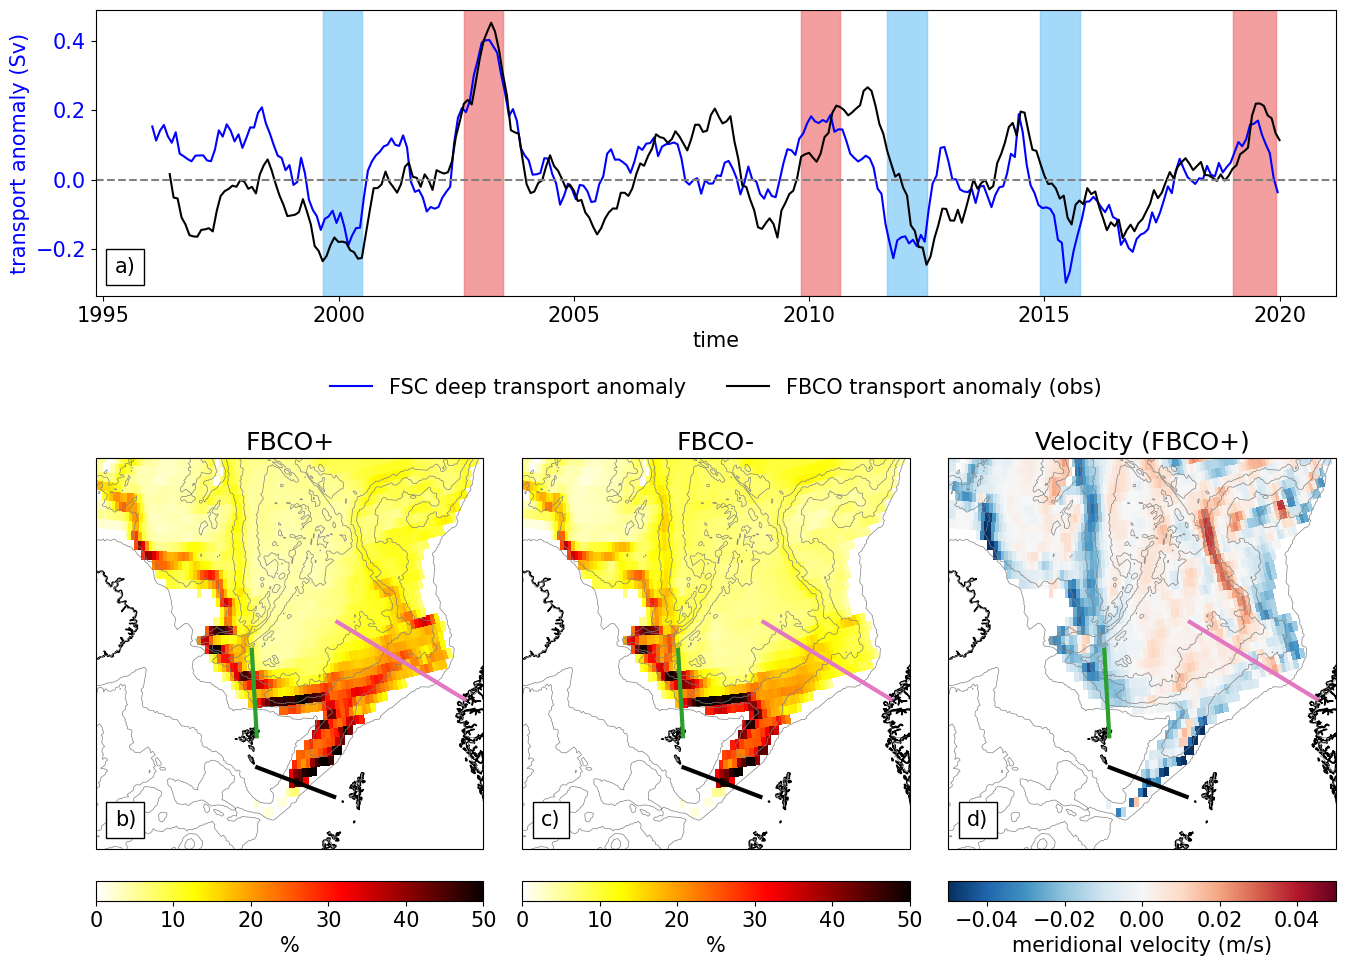

In [19]:
plt.rcParams.update({"font.size": 15})

fig = plt.figure(figsize=(16, 13))  # Wider to accommodate 3 maps
gs = gridspec.GridSpec(
    nrows=2, ncols=3, height_ratios=[0.6, 1.5], hspace=0.0, wspace=0.1
)

# ---- TOP PANEL: TIME SERIES ----
ax1 = fig.add_subplot(gs[0, :])
S_trspt_detrend.sel(time_counter=slice("1996", "2019")).plot(
    ax=ax1, color="blue", label="FSC deep transport anomaly"
)
detrend_dim(
    FBC_obs_trspt_detrend.rolling(time_counter=12, center=True).mean(),
    dim="time_counter",
)[1].sel(time_counter=slice("1996", "2019")).plot(
    ax=ax1, color="k", label="FBCO transport anomaly (obs)"
)
ax1.set_ylabel("transport anomaly (Sv)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# ax2 = ax1.twinx()
# detrend_dim(rolling_mean_NAO, dim="time_counter")[1].sel(
#     time_counter=slice("1996", "2019")
# ).plot(ax=ax2, color="k", alpha=0.4, label="NAO")
# ax2.set_ylabel("NAO (detrended)", color="dimgrey")
# ax2.tick_params(axis="y", labelcolor="dimgrey")


ax1.set_xticks(
    [
        pd.Timestamp("1995-01-01"),
        pd.Timestamp("2000-01-01"),
        pd.Timestamp("2005-01-01"),
        pd.Timestamp("2010-01-01"),
        pd.Timestamp("2015-01-01"),
        pd.Timestamp("2020-01-01"),
    ]
)
ax1.set_xticklabels(["1995", "2000", "2005", "2010", "2015", "2020"])

for start, end, color in [
    ("2019-01-01", "2019-12-01", "lightcoral"),
    ("2002-09-01", "2003-07-01", "lightcoral"),
    ("2009-11-01", "2010-09-01", "lightcoral"),
    ("1999-09-01", "2000-07-01", "lightskyblue"),
    ("2011-09-01", "2012-07-01", "lightskyblue"),
    ("2014-12-01", "2015-10-01", "lightskyblue"),
]:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.5)

# ax2.set_xlim(ax1.get_xlim())

for start, end, color in [
    ("2019-01-01", "2019-12-01", "lightcoral"),
    ("2002-09-01", "2003-07-01", "lightcoral"),
    ("2009-11-01", "2010-09-01", "lightcoral"),
    ("1999-09-01", "2000-07-01", "lightskyblue"),
    ("2011-09-01", "2012-07-01", "lightskyblue"),
    ("2014-12-01", "2015-10-01", "lightskyblue"),
]:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.5)

ax1.axhline(y=0, color="grey", linestyle="dashed")
ax1.set_xlabel("time")

# Anchored label
at = AnchoredText("a)", prop=dict(size=15), frameon=True, loc="lower left")
ax1.add_artist(at)

# Custom Legend
line_legend = [
    # Line2D([0], [0], color="k", alpha=0.4, label="NAO"),
    Line2D([0], [0], color="b", label="FSC deep transport anomaly"),
    Line2D([0], [0], color="k", label="FBCO transport anomaly (obs)"),
]

ax1.legend(
    handles=line_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    frameon=False,
    ncol=3,
)

# ---- BOTTOM PANELS: THREE MAPS ----
axes = [
    fig.add_subplot(
        gs[1, i],
        projection=ccrs.Orthographic(central_longitude=-10, central_latitude=77),
    )
    for i in range(3)
]

# map data for each subplot
map_data = [
    mean_high_transport * msk,
    mean_low_transport * msk,
    mean_vvel_high_trspt_maps * msk,
]
titles = ["FBCO+", "FBCO-", "Velocity (FBCO+)"]
labels = ["b)", "c)", "d)"]
cmaps = ["hot_r", "hot_r", "RdBu_r"]
vmins = [0, 0, -0.05]
vmaxs = [50, 50, 0.05]
cbar_labels = ["%", "%", "meridional velocity (m/s)"]

for i, ax in enumerate(axes):
    ax.set_extent([-15, 5, 59, 69], crs=ccrs.PlateCarree())
    ax.pcolormesh(
        mesh_mask.nav_lon,
        mesh_mask.nav_lat,
        land_mask,
        transform=ccrs.PlateCarree(),
        cmap="binary",
    )

    im = ax.pcolormesh(
        lon,
        lat,
        map_data[i],
        cmap=cmaps[i],
        vmin=vmins[i],
        vmax=vmaxs[i],
        transform=ccrs.PlateCarree(),
    )

    ax.coastlines()
    ax.contour(
        mesh_mask.nav_lon,
        mesh_mask.nav_lat,
        bathymetry,
        levels=contour_levels,
        colors="gray",
        linewidths=0.5,
        alpha=1,
        transform=ccrs.PlateCarree(),
    )

    # # gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    # # gl.xlabels_top = False
    # # gl.ylabels_right = False
    # gl.xlocator = FixedLocator(np.arange(-180, 181, 10))
    # gl.ylocator = FixedLocator(np.arange(-90, 91, 10))
    # gl.xlabel_style = {"size": 15}
    # gl.ylabel_style = {"size": 15}

    ax.plot(
        [5.5, -1],
        [62.24, 65.0],
        color="tab:pink",
        transform=ccrs.PlateCarree(),
        linewidth=3,
    )
    ax.plot(
        [-6.43, -6.43],
        [62.15, 64.5],
        color="tab:green",
        transform=ccrs.PlateCarree(),
        linewidth=3,
    )
    # ax.plot([-15, -11.95], [66.25, 68.7], color='blue', transform=ccrs.PlateCarree())
    ax.plot(
        [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
    )

    ax.set_title(titles[i])
    at = AnchoredText(labels[i], prop=dict(size=15), frameon=True, loc="lower left")
    ax.add_artist(at)

    pos = ax.get_position()
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.04, pos.width, 0.015])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(cbar_labels[i])

plt.tight_layout(rect=[0, 0.1, 1, 1])
# plt.savefig('Fig7_trspt_ts_pathways_with_velocity.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 8

In [20]:
## Svinoy sections high versus low transport

svinoy = xr.open_dataset("/gxfs_work/geomar/smomw452/GLORYS12/Data/Svinoy_section.nc")
svinoy_sigma0 = (
    xr.apply_ufunc(
        sw.eos80.dens0,
        svinoy.vosaline,
        svinoy.votemper,
        dask="parallelized",
        output_dtypes=[np.float64],
    )
    - 1000
)
svinoy_overflow = svinoy.where(svinoy_sigma0 > 28)


# high trspt
input_date_2003 = "2002-09-01", "2003-07-01"
input_date_2009 = "2009-11-01", "2010-09-01"
# input_date_1997 = "1997-11-01", "1998-09-01"
input_date_2019 = "2019-01-01", "2019-12-01"

# low trspt
input_date_2012 = "2011-09-01", "2012-07-01"
input_date_1999 = "1999-01-01", "1999-12-01"
input_date_2014 = "2014-12-01", "2015-10-01"


# Mean fields
vel_2003 = svinoy.u_rot_normal.sel(time_counter=slice(*input_date_2003)).mean(
    dim="time_counter"
)
sal_2003 = svinoy.vosaline.sel(time_counter=slice(*input_date_2003)).mean(
    dim="time_counter"
)
temp_2003 = svinoy.votemper.sel(time_counter=slice(*input_date_2003)).mean(
    dim="time_counter"
)
sigma_2003 = svinoy_sigma0.sel(time_counter=slice(*input_date_2003)).mean(
    dim="time_counter"
)

vel_2009 = svinoy.u_rot_normal.sel(time_counter=slice(*input_date_2009)).mean(
    dim="time_counter"
)
sal_2009 = svinoy.vosaline.sel(time_counter=slice(*input_date_2009)).mean(
    dim="time_counter"
)
temp_2009 = svinoy.votemper.sel(time_counter=slice(*input_date_2009)).mean(
    dim="time_counter"
)
sigma_2009 = svinoy_sigma0.sel(time_counter=slice(*input_date_2009)).mean(
    dim="time_counter"
)

vel_2019 = svinoy.u_rot_normal.sel(time_counter=slice(*input_date_2019)).mean(
    dim="time_counter"
)
sal_2019 = svinoy.vosaline.sel(time_counter=slice(*input_date_2019)).mean(
    dim="time_counter"
)
temp_2019 = svinoy.votemper.sel(time_counter=slice(*input_date_2019)).mean(
    dim="time_counter"
)


vel_2012 = svinoy.u_rot_normal.sel(time_counter=slice(*input_date_2012)).mean(
    dim="time_counter"
)
sal_2012 = svinoy.vosaline.sel(time_counter=slice(*input_date_2012)).mean(
    dim="time_counter"
)
temp_2012 = svinoy.votemper.sel(time_counter=slice(*input_date_2012)).mean(
    dim="time_counter"
)
sigma_2012 = svinoy_sigma0.sel(time_counter=slice(*input_date_2012)).mean(
    dim="time_counter"
)


def high_trspt(data):
    slices_high_trspt = [
        data.sel(time_counter=slice(*input_date_2019)),
        data.sel(time_counter=slice(*input_date_2003)),
        data.sel(time_counter=slice(*input_date_2009)),
    ]
    return slices_high_trspt


def low_trspt(data):
    slices_low_trspt = [
        data.sel(time_counter=slice(*input_date_2012)),
        data.sel(time_counter=slice(*input_date_1999)),
        data.sel(time_counter=slice(*input_date_2014)),
    ]
    return slices_low_trspt


high_trspt_svinoy = xr.concat(high_trspt(svinoy), dim="time_counter").mean(
    dim="time_counter"
)

high_trspt_sigma_svinoy = xr.concat(high_trspt(svinoy_sigma0), dim="time_counter").mean(
    dim="time_counter"
)

low_trspt_svinoy = xr.concat(low_trspt(svinoy), dim="time_counter").mean(
    dim="time_counter"
)
low_trspt_sigma_svinoy = xr.concat(low_trspt(svinoy_sigma0), dim="time_counter").mean(
    dim="time_counter"
)

# Difference
vel_diff = high_trspt_svinoy.u_rot_normal - low_trspt_svinoy.u_rot_normal
sal_diff = high_trspt_svinoy.vosaline - low_trspt_svinoy.vosaline
temp_diff = high_trspt_svinoy.votemper - low_trspt_svinoy.votemper

cmap_vel = plt.get_cmap("bwr")
cmap_vel.set_bad(color="gray")

cmap_sal = plt.get_cmap("PuOr_r")
cmap_sal.set_bad(color="gray")


cmap_temp = plt.get_cmap("RdBu_r")
cmap_temp.set_bad(color="gray")

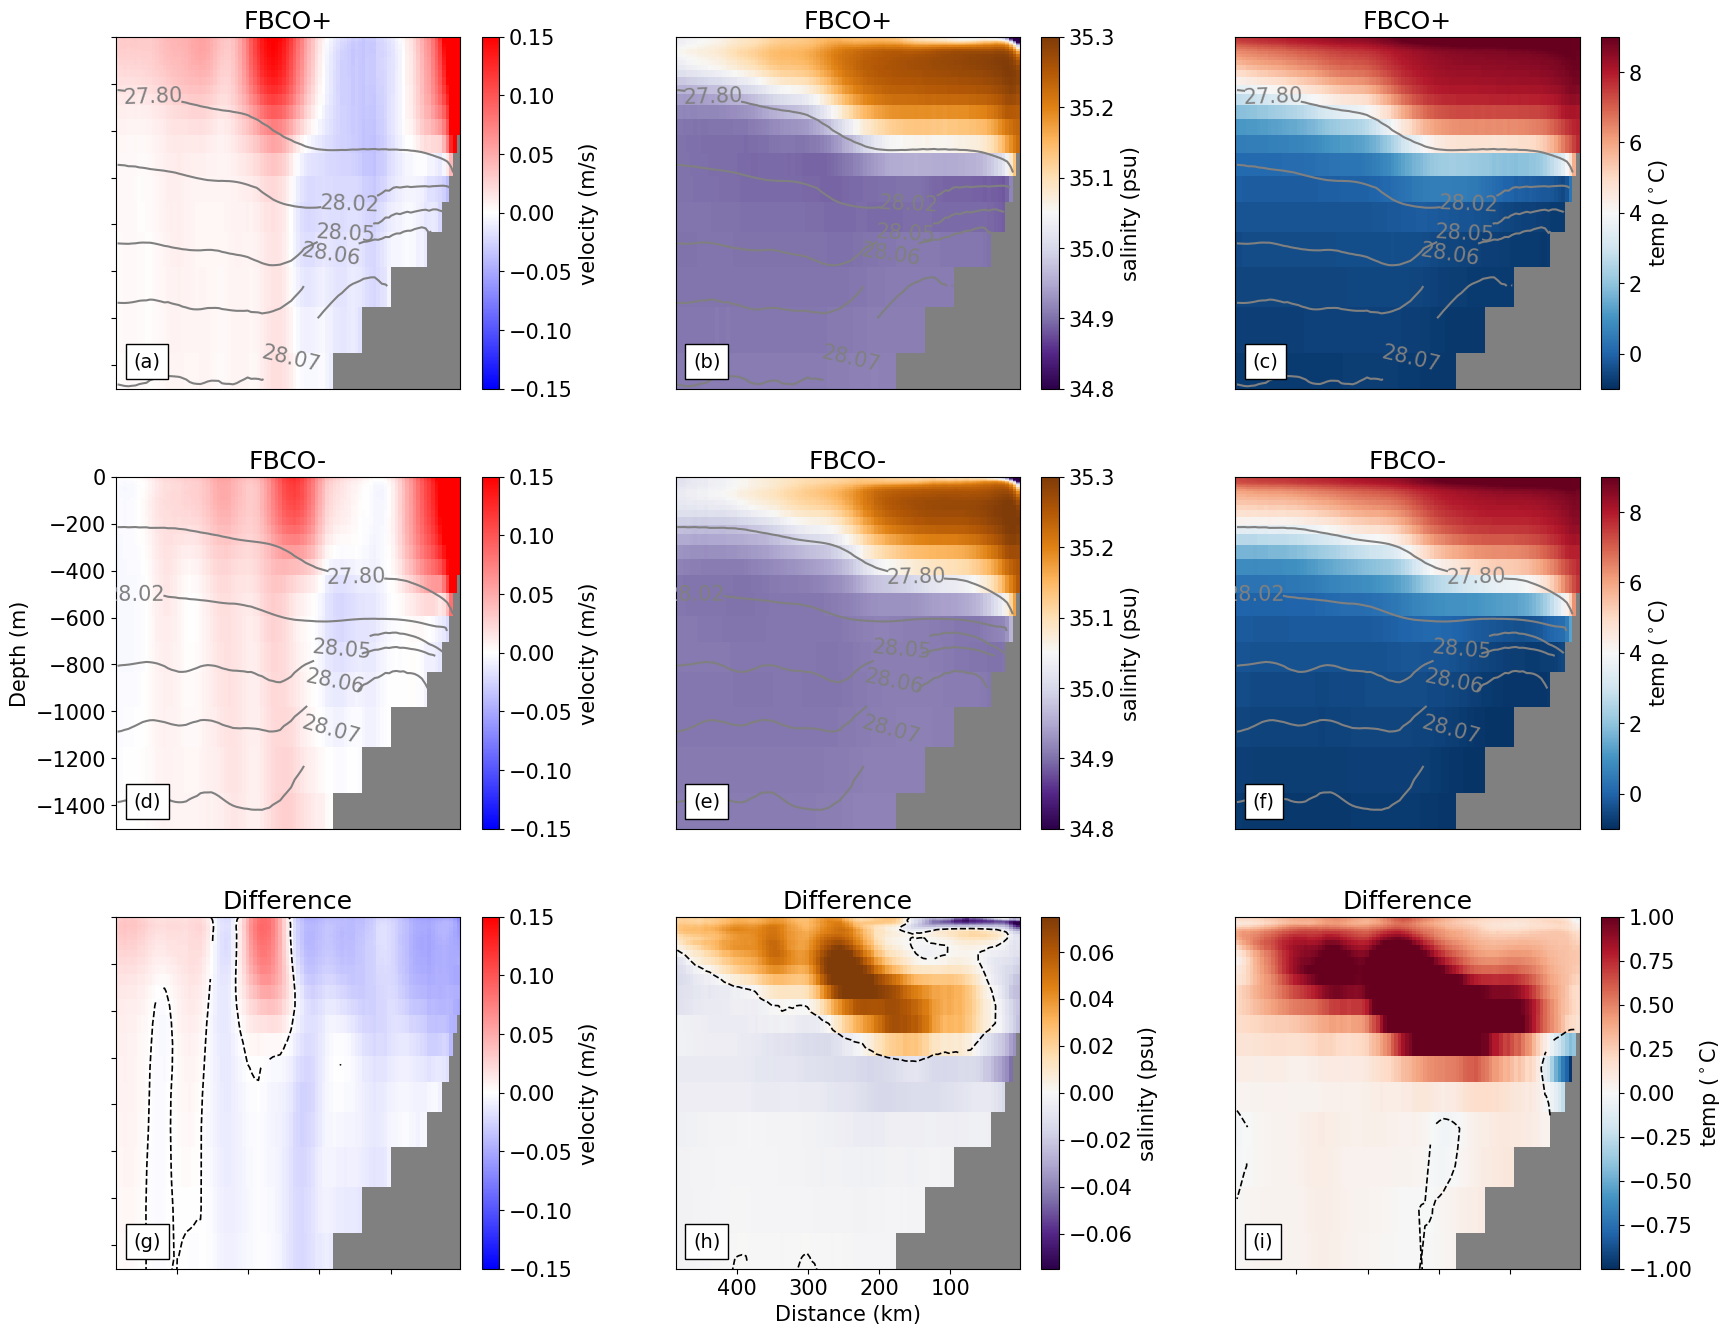

In [21]:
# === Figure layout ===
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, hspace=0.25, wspace=0.3)

labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]
label_idx = 0

# === 3x3 hydrography section plots ===
for row, (vel, sal, temp, sigma, label, diff_flag) in enumerate(
    [
        (
            high_trspt_svinoy.u_rot_normal,
            high_trspt_svinoy.vosaline,
            high_trspt_svinoy.votemper,
            high_trspt_sigma_svinoy,
            "FBCO+",
            False,
        ),
        (
            low_trspt_svinoy.u_rot_normal,
            low_trspt_svinoy.vosaline,
            low_trspt_svinoy.votemper,
            low_trspt_sigma_svinoy,
            "FBCO-",
            False,
        ),
        (vel_diff, sal_diff, temp_diff, None, "Difference", True),
    ]
):
    for col, (data, cmap, vmin, vmax, varname) in enumerate(
        [
            (vel, cmap_vel, -0.15, 0.15, "velocity (m/s)"),
            (
                sal,
                cmap_sal,
                -0.075 if diff_flag else 34.8,
                0.075 if diff_flag else 35.3,
                "salinity (psu)",
            ),
            (temp, cmap_temp, -1.0, 1.0 if diff_flag else 9, r"temp ($^\circ$C)"),
        ]
    ):
        ax = fig.add_subplot(gs[row, col])
        pc = ax.pcolormesh(
            svinoy.c / 1e3, -svinoy.z, data, cmap=cmap, vmin=vmin, vmax=vmax
        )

        # Sigma contours for non-difference rows
        if not diff_flag and sigma is not None:
            CS = ax.contour(
                svinoy.c / 1e3,
                -svinoy.z,
                sigma,
                [27.8, 28.02, 28.05, 28.06, 28.07, 28.08],
                colors="gray",
            )
            ax.clabel(CS, inline=True, fontsize=15)

        # Zero-difference contour for difference rows
        elif diff_flag:
            CS0 = ax.contour(
                svinoy.c / 1e3,
                -svinoy.z,
                data,
                levels=[0],
                colors="black",
                linewidths=1.2,
                linestyles="dashed",
            )
            ax.clabel(CS0, inline=True, fmt="", fontsize=12)

        # --- Depth (y) axis ---
        # Full labels + ylabel: top-left panel only
        if row == 1 and col == 0:
            ax.set_ylabel("Depth (m)")
        # Tick marks only, no labels: remaining left column
        elif col == 0:
            ax.tick_params(labelleft=False)
        # No ticks or labels: all other columns
        else:
            ax.tick_params(labelleft=False, left=False)

        # --- Distance (x) axis ---
        # Full label: bottom centre only
        if row == 2 and col == 1:
            ax.set_xlabel("Distance (km)")
        # Tick marks only, no labels: rest of bottom row
        elif row == 2:
            ax.tick_params(labelbottom=False)
        # No ticks or labels: all non-bottom rows
        else:
            ax.tick_params(labelbottom=False, bottom=False)

        ax.set_ylim(-1500, 0)
        ax.invert_xaxis()
        ax.set_title(label)
        fig.colorbar(pc, ax=ax).set_label(varname)

        at = AnchoredText(
            labels[label_idx], loc="lower left", prop=dict(size=14), frameon=True
        )
        ax.add_artist(at)
        label_idx += 1

plt.tight_layout()
# plt.savefig("Fig8_svinoy_sec_hydrography.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 9

In [25]:
ds = xr.open_dataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/svinoy_expt/level2/svinoy_parcels_releases_seed-2345.zarr",
    engine="zarr",
    chunks="auto",
)

ds = filter_beached_particles(ds, "obs")

ds = ds.where(ds.age * hours_to_years < 2, drop=False)

p = ds
p["start_time"] = p.isel(obs=0).time
p = p.set_coords("start_time")
p = p.set_xindex("start_time")

# Get S section and particles that only cross the S sec

S = (ds.lon < -2.5) & (ds.lat > 60.3) & (ds.lon > -6.5) & (ds.lat < 61.3)

S_box = ds.where(S, drop=False)


# Calculate slope and intercept
dist = 0.3
m_S, b_S = calculate_slope_intercept(-6.5, 61.3 - dist, -2.5, 60.3 - dist)
m_S2, b_S2 = calculate_slope_intercept(
    -6.5, 61.3 + dist, -2.5, 60.3 + dist
)  # .8 comes from max 2m/s velocity*12h = 86km convert km to degree = ~.77 degree

print("slope (m) is:", m_S)
print("y-intercept (b) is:", b_S)

ds_S_window = (
    S_box.lat >= S_box.lon * m_S + b_S
)  # if latitude above that line, set to True
ds_S_window2 = (
    S_box.lat <= S_box.lon * m_S2 + b_S2
)  # if latitude BELOW that line, set to True
ds_S_line_cross = (S_box.lat >= S_box.lon * m_S + b_S) & (
    S_box.lat <= S_box.lon * m_S2 + b_S2
)

ds_S_window = ds_S_window.astype(int)
ds_S_window2 = ds_S_window2.astype(int)
ds_S_line_cross = ds_S_line_cross.astype(int)

# ds_S_window
ds_S = ds.where(ds_S_window, drop=False)
ds_S2 = ds.where(ds_S_window2, drop=False)

ds_S_line = ds.where(ds_S_window & ds_S_window2, drop=False)

S_line_cross = filter_trajectories(ds_S, p)

hmap_S_line = compute_probability_perc(S_line_cross["traj_line"])
lon, lat = hmap_S_line.lon.values, hmap_S_line.lat.values

slope (m) is: -0.25
y-intercept (b) is: 59.375


In [26]:
Svinoy_crossing_only_heatmap = xr.open_dataset(
    "netcdfs/heatmaps_svinoy_crossing_only.nc"
).Svinoy_crossing_only_heatmap

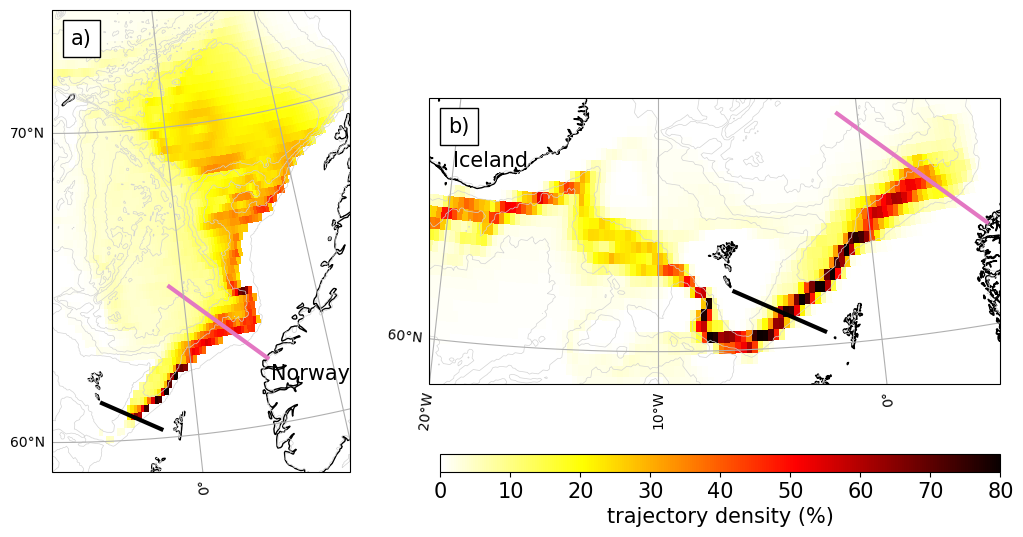

In [27]:
# Define the projection
proj = ccrs.LambertConformal(central_longitude=-10, central_latitude=70)

# Create figure with 2 maps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": proj})

labels = ["a)", "b)"]
label_idx = 0

# ----------------- Left map -----------------
ax1.set_extent([-10, 10, 59, 73], crs=ccrs.PlateCarree())
m1 = ax1.pcolormesh(
    Svinoy_crossing_only_heatmap.lon,
    Svinoy_crossing_only_heatmap.lat,
    Svinoy_crossing_only_heatmap * msk,
    cmap="hot_r",
    vmin=0,
    vmax=80,
    transform=ccrs.PlateCarree(),
)

ax1.coastlines()
ax1.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    alpha=1,
    transform=ccrs.PlateCarree(),
)

gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 10))
gl.ylocator = plt.FixedLocator(np.arange(-90, 91, 10))
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

ax1.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
# ax1.plot(
#     [-6.43, -6.43],
#     [62.15, 64.5],
#     color="tab:green",
#     linewidth=3,
#     transform=ccrs.PlateCarree(),
# )
ax1.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", linewidth=3, transform=ccrs.PlateCarree()
)

at1 = AnchoredText(
    labels[label_idx], loc="upper left", prop=dict(size=15), frameon=True
)
ax1.add_artist(at1)
label_idx += 1

# ----------------- Right map -----------------
ax2.set_extent([-20, 5, 59, 65], crs=ccrs.PlateCarree())
ax2.pcolormesh(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    land_mask,
    cmap="binary",
    transform=ccrs.PlateCarree(),
)
m2 = ax2.pcolormesh(
    lon, lat, hmap_S_line, cmap="hot_r", vmin=0, vmax=80, transform=ccrs.PlateCarree()
)

ax2.coastlines()
ax2.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    alpha=1,
    transform=ccrs.PlateCarree(),
)

gl = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 10))
gl.ylocator = plt.FixedLocator(np.arange(-90, 91, 10))
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

ax2.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
# ax2.plot(
#     [-6.43, -6.43],
#     [62.15, 64.5],
#     color="tab:green",
#     linewidth=3,
#     transform=ccrs.PlateCarree(),
# )
ax2.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", linewidth=3, transform=ccrs.PlateCarree()
)

at2 = AnchoredText(
    labels[label_idx], loc="upper left", prop=dict(size=15), frameon=True
)
ax2.add_artist(at2)

ax2.text(-20, 63.8, "Iceland", transform=ccrs.PlateCarree())

ax1.text(5.5, 61.5, "Norway", transform=ccrs.PlateCarree())
# Create a custom axes for the colorbar: [left, bottom, width, height] in figure coordinates
cbax = fig.add_axes([0.5, 0.11, 0.4, 0.03])

# Create the colorbar in that axes
cbar = fig.colorbar(m1, cax=cbax, orientation="horizontal")
cbar.set_label("trajectory density (%)")


# Reduce horizontal space between maps
plt.subplots_adjust(wspace=-0.1)
# plt.savefig("Fig9_svinoy_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 10

In [28]:
svinoy_annual_mean = svinoy.groupby("time_counter.year").mean(dim="time_counter")
svinoy_southward_only = svinoy.where(svinoy.u_rot_normal < 0).sel(c=slice(0, 150e3))
svinoy_southward_overflow = svinoy_southward_only.where(svinoy_sigma0 > 28)


def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return fit, da - fit


svinoy_trspt = bl.calculate_transport(
    svinoy_southward_only.sel(z=slice(500, None))
).trsp

S_trspt = xr.open_dataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/notebooks/CLEANUP_notebooks/S_trspt_1.nc"
).S_trspt
S_trspt_seasonlity_remove = S_trspt.groupby("time_counter.month") - S_trspt.groupby(
    "time_counter.month"
).mean(dim="time_counter")
S_trspt_seasonlity_remove_detrend = detrend_dim(
    S_trspt_seasonlity_remove, "time_counter"
)[1]
S_trspt_detrend = detrend_dim(
    S_trspt_seasonlity_remove.rolling(time_counter=12, center=True).mean(),
    dim="time_counter",
)[1].sel(time_counter=slice("1996", "2019"))


def remove_seasonality(data):
    return data.groupby("time_counter.month") - data.groupby("time_counter.month").mean(
        dim="time_counter"
    )

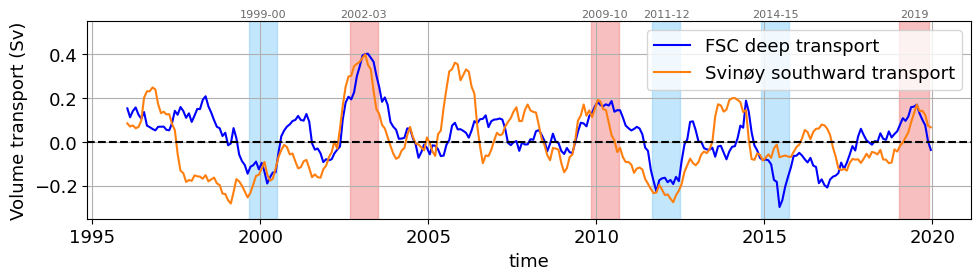

In [31]:
plt.rcParams.update({"font.size": 13})

fig, ax1 = plt.subplots(figsize=(10, 3))

(S_trspt_detrend).plot(ax=ax1, color="blue", label="FSC deep transport")
(
    -detrend_dim(
        bl.calculate_transport(svinoy_southward_only.sel(z=slice(500, None)))
        .trsp.rolling(time_counter=12, center=True)
        .mean()
        .sel(time_counter=slice("1996", "2019")),
        "time_counter",
    )[1]
).plot(ax=ax1, color="tab:orange", label="Svinøy southward transport")

ax1.set_ylabel("Volume transport (Sv)", color="k")
ax1.tick_params(axis="y", labelcolor="k")

spans = [
    ("2002-09-01", "2003-07-01", "lightcoral", "2002-03"),
    ("2009-11-01", "2010-09-01", "lightcoral", "2009-10"),
    ("2019-01-01", "2019-12-01", "lightcoral", "2019"),
    ("2011-09-01", "2012-07-01", "lightskyblue", "2011-12"),
    ("1999-09-01", "2000-07-01", "lightskyblue", "1999-00"),
    ("2014-12-01", "2015-10-01", "lightskyblue", "2014-15"),
]

trans = blended_transform_factory(ax1.transData, ax1.transAxes)

for start, end, color, label in spans:
    t0 = pd.to_datetime(start)
    t1 = pd.to_datetime(end)
    mid = t0 + (t1 - t0) / 2
    ax1.axvspan(t0, t1, color=color, alpha=0.5)
    ax1.text(
        mid,
        1.01,
        label,  # y > 1 = above the axes
        transform=trans,
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,  # horizontal
        color="dimgrey",
        clip_on=False,  # allow drawing outside axes bounds
    )

ax1.legend(loc="upper right")

ax1.set_xticks(
    [
        pd.Timestamp("1995-01-01"),
        pd.Timestamp("2000-01-01"),
        pd.Timestamp("2005-01-01"),
        pd.Timestamp("2010-01-01"),
        pd.Timestamp("2015-01-01"),
        pd.Timestamp("2020-01-01"),
    ]
)
ax1.set_xticklabels(["1995", "2000", "2005", "2010", "2015", "2020"])

ax1.set_xlabel("time")
ax1.set_ylim(-0.35, 0.55)

plt.axhline(y=0, linestyle="dashed", color="k")
plt.grid()
plt.tight_layout()
# plt.savefig("Fig9_FSC_Svinoy_transport_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()